In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


FEATURE_PATH = Path("door_cycle_features.csv")

print("Feature file exists:", FEATURE_PATH.exists())

cycle_features = pd.read_csv(FEATURE_PATH)

print("Feature table shape:", cycle_features.shape)
display(cycle_features.head())

Feature file exists: True
Feature table shape: (110, 143)


,Motor current(mA)_mean,Motor current(mA)_std,Motor current(mA)_min,Motor current(mA)_max,Motor current(mA)_range,Motor Voltage(10mV)_mean,Motor Voltage(10mV)_std,Motor Voltage(10mV)_min,Motor Voltage(10mV)_max,Motor Voltage(10mV)_range,Motor electrodynamic force_mean,Motor electrodynamic force_std,Motor electrodynamic force_max,Motor electrodynamic force_range,Door leaf position_mean,Door leaf position_std,Door leaf position_min,Door leaf position_max,Door leaf position_range,Motor current(mA)_phase1_mean,Motor current(mA)_phase1_std,Motor current(mA)_phase1_min,Motor current(mA)_phase1_max,Motor current(mA)_phase1_range,Motor current(mA)_phase2_mean,Motor current(mA)_phase2_std,Motor current(mA)_phase2_min,Motor current(mA)_phase2_max,Motor current(mA)_phase2_range,Motor current(mA)_phase3_mean,Motor current(mA)_phase3_std,Motor current(mA)_phase3_min,Motor current(mA)_phase3_max,Motor current(mA)_phase3_range,Motor current(mA)_phase4_mean,Motor current(mA)_phase4_std,Motor current(mA)_phase4_min,Motor current(mA)_phase4_max,Motor current(mA)_phase4_range,Motor current(mA)_phase5_mean,Motor current(mA)_phase5_std,Motor current(mA)_phase5_min,Motor current(mA)_phase5_max,Motor current(mA)_phase5_range,Motor Voltage(10mV)_phase1_mean,Motor Voltage(10mV)_phase1_std,Motor Voltage(10mV)_phase1_min,Motor Voltage(10mV)_phase1_max,Motor Voltage(10mV)_phase1_range,Motor Voltage(10mV)_phase2_mean,Motor Voltage(10mV)_phase2_std,Motor Voltage(10mV)_phase2_min,Motor Voltage(10mV)_phase2_max,Motor Voltage(10mV)_phase2_range,Motor Voltage(10mV)_phase3_mean,Motor Voltage(10mV)_phase3_std,Motor Voltage(10mV)_phase3_min,Motor Voltage(10mV)_phase3_max,Motor Voltage(10mV)_phase3_range,Motor Voltage(10mV)_phase4_mean,Motor Voltage(10mV)_phase4_std,Motor Voltage(10mV)_phase4_min,Motor Voltage(10mV)_phase4_max,Motor Voltage(10mV)_phase4_range,Motor Voltage(10mV)_phase5_mean,Motor Voltage(10mV)_phase5_std,Motor Voltage(10mV)_phase5_min,Motor Voltage(10mV)_phase5_max,Motor Voltage(10mV)_phase5_range,Motor electrodynamic force_phase1_mean,Motor electrodynamic force_phase1_std,Motor electrodynamic force_phase1_min,Motor electrodynamic force_phase1_max,Motor electrodynamic force_phase1_range,Motor electrodynamic force_phase2_mean,Motor electrodynamic force_phase2_std,Motor electrodynamic force_phase2_min,Motor electrodynamic force_phase2_max,Motor electrodynamic force_phase2_range,Motor electrodynamic force_phase3_mean,Motor electrodynamic force_phase3_std,Motor electrodynamic force_phase3_min,Motor electrodynamic force_phase3_max,Motor electrodynamic force_phase3_range,Motor electrodynamic force_phase4_mean,Motor electrodynamic force_phase4_std,Motor electrodynamic force_phase4_min,Motor electrodynamic force_phase4_max,Motor electrodynamic force_phase4_range,Motor electrodynamic force_phase5_mean,Motor electrodynamic force_phase5_std,Motor electrodynamic force_phase5_max,Motor electrodynamic force_phase5_range,Door leaf position_phase1_mean,Door leaf position_phase1_std,Door leaf position_phase1_min,Door leaf position_phase1_max,Door leaf position_phase1_range,Door leaf position_phase2_mean,Door leaf position_phase2_std,Door leaf position_phase2_min,Door leaf position_phase2_max,Door leaf position_phase2_range,Door leaf position_phase3_mean,Door leaf position_phase3_std,Door leaf position_phase3_min,Door leaf position_phase3_max,Door leaf position_phase3_range,Door leaf position_phase4_mean,Door leaf position_phase4_std,Door leaf position_phase4_min,Door leaf position_phase4_max,Door leaf position_phase4_range,Door leaf position_phase5_mean,Door leaf position_phase5_std,Door leaf position_phase5_min,Door leaf position_phase5_max,Door leaf position_phase5_range,position_diff_mean,position_diff_std,position_diff_min,position_diff_max,position_diff_abs_mean,position_diff_abs_max,current_diff_mean,current_diff_std,current_diff_min,current_diff_max,current_diff_abs_mean,current_diff_abs_max,position_abs_diff_mean,position_abs_diff_std,position_abs_diff_max

In [13]:
# Separate metadata and target columns from the numerical model features.

metadata_columns = ["segment_id", "operation", "status"]
numeric_features = [column for column in cycle_features.columns if column not in metadata_columns]

X = cycle_features[numeric_features].copy()
y = cycle_features["status"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (110, 140)
y shape: (110,)


In [14]:
# Encode Normal as 0 and Abnormal resistance as 1.

y_binary = y.map({"Normal": 0, "Abnormal resistance": 1})

print("Encoded labels:", sorted(y_binary.unique()))
display(pd.DataFrame({"status": y, "encoded": y_binary}).head())

Encoded labels: [np.int64(0), np.int64(1)]


,status,encoded
0,Normal,0
1,Normal,0
2,Abnormal resistance,1
3,Abnormal resistance,1
4,Abnormal resistance,1


In [15]:
# Inspect the class distribution before model training.

print("Class counts:")
display(y.value_counts())

print("\nClass proportions:")
display(y.value_counts(normalize=True))

Class counts:


status
Normal                 80
Abnormal resistance    30
Name: count, dtype: int64


Class proportions:


status
Normal                 0.727273
Abnormal resistance    0.272727
Name: proportion, dtype: float64

In [16]:
# Use stratified 5-fold cross-validation so each fold retains the Normal/Abnormal ratio.

RANDOM_STATE = 42
N_SPLITS = 5

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print("Number of folds:", N_SPLITS)
print("Random state:", RANDOM_STATE)

Number of folds: 5
Random state: 42


In [17]:
# Calculate the main classification metrics used throughout the notebook.


def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "abnormal_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "abnormal_recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "abnormal_f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

In [18]:
# Print a detailed report for a prediction set.


def print_results(y_true, y_pred):
    results = evaluate_predictions(y_true, y_pred)
    display(pd.DataFrame([results]))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["Normal", "Abnormal resistance"], zero_division=0))

## Baseline Models

In [20]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
    "Linear SVM": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="linear"))]),
    "RBF SVM": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", C=1.0, gamma="scale"))]),
    "Random Forest": RandomForestClassifier(n_estimators=500, max_depth=4, min_samples_leaf=2, random_state=RANDOM_STATE),
}

print("\n".join(models.keys()))

Dummy
Logistic Regression
Linear SVM
RBF SVM
Random Forest


In [21]:
# Generate out-of-fold predictions for every baseline model.

results = []
predictions = {}

for name, model in models.items():
    pred = cross_val_predict(model, X, y_binary, cv=cv, method="predict")
    metrics = evaluate_predictions(y_binary, pred)
    metrics["model"] = name
    results.append(metrics)
    predictions[name] = pred

results = pd.DataFrame(results).set_index("model")

display(results)

,accuracy,balanced_accuracy,macro_f1,abnormal_precision,abnormal_recall,abnormal_f1
model,,,,,,
Dummy,0.727273,0.5,0.421053,0.0,0.0,0.0
Logistic Regression,1.000000,1.0,1.000000,1.0,1.0,1.0
Linear SVM,1.000000,1.0,1.000000,1.0,1.0,1.0
RBF SVM,1.000000,1.0,1.000000,1.0,1.0,1.0
Random Forest,1.000000,1.0,1.000000,1.0,1.0,1.0


In [22]:
# Show the model comparison ordered by the competition-equivalent accuracy.

display(results[["accuracy", "macro_f1", "abnormal_precision", "abnormal_recall", "abnormal_f1", "balanced_accuracy"]].sort_values("accuracy", ascending=False))

,accuracy,macro_f1,abnormal_precision,abnormal_recall,abnormal_f1,balanced_accuracy
model,,,,,,
Logistic Regression,1.000000,1.000000,1.0,1.0,1.0,1.0
Linear SVM,1.000000,1.000000,1.0,1.0,1.0,1.0
RBF SVM,1.000000,1.000000,1.0,1.0,1.0,1.0
Random Forest,1.000000,1.000000,1.0,1.0,1.0,1.0
Dummy,0.727273,0.421053,0.0,0.0,0.0,0.5


In [23]:
# Inspect the confusion matrix for each baseline classifier.

for name, pred in predictions.items():
    print(f"\n{name}")
    print(confusion_matrix(y_binary, pred))


Dummy
[[80  0]
 [30  0]]

Logistic Regression
[[80  0]
 [ 0 30]]

Linear SVM
[[80  0]
 [ 0 30]]

RBF SVM
[[80  0]
 [ 0 30]]

Random Forest
[[80  0]
 [ 0 30]]


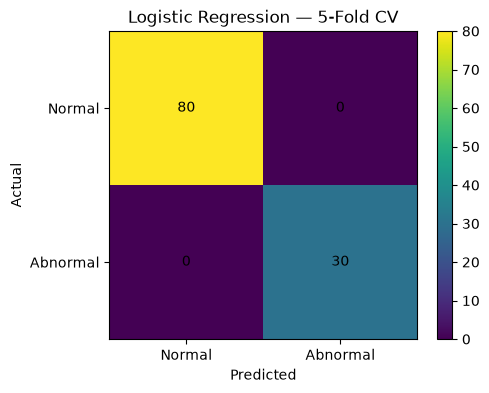

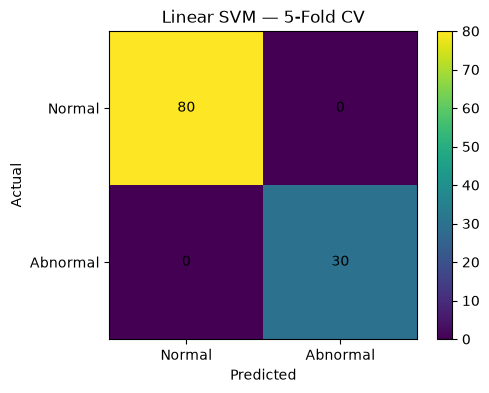

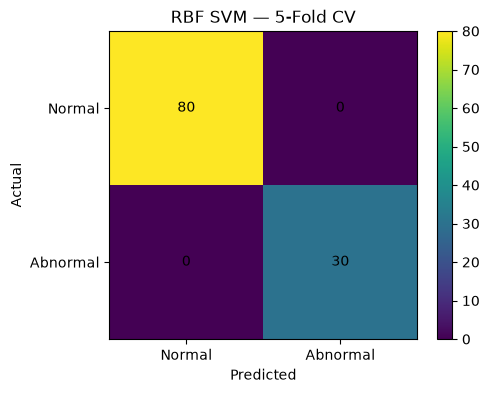

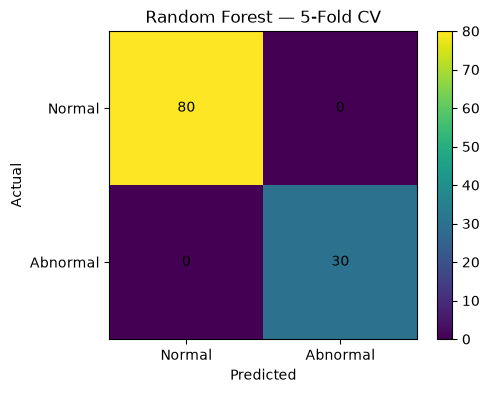

In [24]:
# Plot the confusion matrix for each baseline classifier.

model_names = ["Logistic Regression", "Linear SVM", "RBF SVM", "Random Forest"]

for name in model_names:
    matrix = confusion_matrix(y_binary, predictions[name])

    plt.figure(figsize=(5, 4))
    plt.imshow(matrix)

    plt.xticks([0, 1], ["Normal", "Abnormal"])
    plt.yticks([0, 1], ["Normal", "Abnormal"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} — 5-Fold CV")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, matrix[i, j], ha="center", va="center")

    plt.colorbar()
    plt.show()

In [25]:
# Evaluate Logistic Regression using several feature-set sizes.

feature_sizes = [5, 10, 20, 40, "all"]

selection_results = []

for k in feature_sizes:
    selector = SelectKBest(score_func=f_classif, k=k)
    model = Pipeline([("selector", selector), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])

    pred = cross_val_predict(model, X, y_binary, cv=cv, method="predict")
    metrics = evaluate_predictions(y_binary, pred)
    metrics["k"] = k
    selection_results.append(metrics)

selection_results = pd.DataFrame(selection_results)

display(
    selection_results[["k", "accuracy", "macro_f1", "abnormal_precision", "abnormal_recall", "abnormal_f1", "balanced_accuracy"]].sort_values(
        "accuracy", ascending=False
    )
)

,k,accuracy,macro_f1,abnormal_precision,abnormal_recall,abnormal_f1,balanced_accuracy
3,40,1.000000,1.00000,1.0,1.000000,1.000000,1.000000
4,all,1.000000,1.00000,1.0,1.000000,1.000000,1.000000
0,5,0.990909,0.98842,1.0,0.966667,0.983051,0.983333
1,10,0.990909,0.98842,1.0,0.966667,0.983051,0.983333
2,20,0.990909,0.98842,1.0,0.966667,0.983051,0.983333


In [26]:
# Identify the strongest feature-set size based on the cross-validation results.

best_k = selection_results.sort_values("accuracy", ascending=False).iloc[0]["k"]

print("Best feature count according to CV:", best_k)

Best feature count according to CV: 40


In [27]:
# Fit the selector on the full dataset only to inspect which features were selected.

best_selector = SelectKBest(score_func=f_classif, k=best_k)
best_selector.fit(X, y_binary)

selected_features = X.columns[best_selector.get_support()]

print("Selected features:", len(selected_features))

for feature in selected_features:
    print(feature)

Selected features: 40
Motor current(mA)_mean
Motor current(mA)_min
Motor Voltage(10mV)_min
Door leaf position_min
Motor current(mA)_phase1_std
Motor current(mA)_phase1_min
Motor current(mA)_phase1_max
Motor current(mA)_phase1_range
Motor current(mA)_phase2_mean
Motor current(mA)_phase2_std
Motor current(mA)_phase2_min
Motor current(mA)_phase2_max
Motor current(mA)_phase2_range
Motor current(mA)_phase3_mean
Motor current(mA)_phase3_std
Motor current(mA)_phase3_min
Motor current(mA)_phase3_max
Motor current(mA)_phase3_range
Motor current(mA)_phase4_mean
Motor current(mA)_phase4_min
Motor Voltage(10mV)_phase1_min
Motor Voltage(10mV)_phase2_std
Motor Voltage(10mV)_phase2_range
Motor Voltage(10mV)_phase3_min
Motor Voltage(10mV)_phase4_mean
Motor Voltage(10mV)_phase4_min
Motor Voltage(10mV)_phase4_max
Motor Voltage(10mV)_phase5_mean
Motor electrodynamic force_phase1_mean
Motor electrodynamic force_phase2_std
Motor electrodynamic force_phase2_range
Motor electrodynamic force_phase3_std
Motor 

In [28]:
# Compare Logistic Regression with and without the Open/Close operation feature.

X_with_operation = X.copy()
X_without_operation = X.drop(columns=["is_close"])

combined_model = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])

pred_with_operation = cross_val_predict(combined_model, X_with_operation, y_binary, cv=cv, method="predict")
pred_without_operation = cross_val_predict(combined_model, X_without_operation, y_binary, cv=cv, method="predict")

operation_results = pd.DataFrame(
    {"with_operation": evaluate_predictions(y_binary, pred_with_operation), "without_operation": evaluate_predictions(y_binary, pred_without_operation)}
)

display(operation_results)

,with_operation,without_operation
accuracy,1.0,1.0
balanced_accuracy,1.0,1.0
macro_f1,1.0,1.0
abnormal_precision,1.0,1.0
abnormal_recall,1.0,1.0
abnormal_f1,1.0,1.0


In [29]:
# Evaluate the Logistic Regression predictions separately for Open and Close cycles.

operation_analysis = []

for operation in ["Open", "Close"]:
    mask = cycle_features["operation"] == operation

    metrics = evaluate_predictions(y_binary[mask], pred_with_operation[mask])

    metrics["operation"] = operation
    operation_analysis.append(metrics)

operation_analysis = pd.DataFrame(operation_analysis).set_index("operation")

display(operation_analysis)

,accuracy,balanced_accuracy,macro_f1,abnormal_precision,abnormal_recall,abnormal_f1
operation,,,,,,
Open,1.0,1.0,1.0,1.0,1.0,1.0
Close,1.0,1.0,1.0,1.0,1.0,1.0


In [30]:
# Identify the cycles that Logistic Regression classified incorrectly.

error_mask = pred_with_operation != y_binary

errors = cycle_features.loc[error_mask, ["segment_id", "operation", "status"]].copy()

errors["predicted_status"] = np.where(pred_with_operation[error_mask] == 1, "Abnormal resistance", "Normal")

display(errors)

,segment_id,operation,status,predicted_status


In [31]:
# Summarise classification mistakes by operation and true status.

display(pd.crosstab(errors["operation"], [errors["status"], errors["predicted_status"]]))

operation


In [32]:
# Evaluate Logistic Regression one fold at a time to see how much performance varies.

fold_results = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y_binary), start=1):
    model = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])

    model.fit(X.iloc[train_idx], y_binary.iloc[train_idx])

    pred = model.predict(X.iloc[val_idx])

    metrics = evaluate_predictions(y_binary.iloc[val_idx], pred)

    metrics["fold"] = fold
    fold_results.append(metrics)

fold_results = pd.DataFrame(fold_results).set_index("fold")

display(fold_results)

,accuracy,balanced_accuracy,macro_f1,abnormal_precision,abnormal_recall,abnormal_f1
fold,,,,,,
1,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0
5,1.0,1.0,1.0,1.0,1.0,1.0


In [33]:
# Summarise the mean and variability of Logistic Regression performance across folds.

fold_summary = fold_results.agg(["mean", "std"])

display(fold_summary)

,accuracy,balanced_accuracy,macro_f1,abnormal_precision,abnormal_recall,abnormal_f1
mean,1.0,1.0,1.0,1.0,1.0,1.0
std,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
# Combine the main baseline comparison into one final table.

final_results = results[["accuracy", "balanced_accuracy", "macro_f1", "abnormal_precision", "abnormal_recall", "abnormal_f1"]].copy()

display(final_results.sort_values("accuracy", ascending=False))

,accuracy,balanced_accuracy,macro_f1,abnormal_precision,abnormal_recall,abnormal_f1
model,,,,,,
Logistic Regression,1.000000,1.0,1.000000,1.0,1.0,1.0
Linear SVM,1.000000,1.0,1.000000,1.0,1.0,1.0
RBF SVM,1.000000,1.0,1.000000,1.0,1.0,1.0
Random Forest,1.000000,1.0,1.000000,1.0,1.0,1.0
Dummy,0.727273,0.5,0.421053,0.0,0.0,0.0


In [35]:
# Save the out-of-fold predictions for later error analysis.

oof_predictions = cycle_features[["segment_id", "operation", "status"]].copy()

for name, pred in predictions.items():
    column_name = name.lower().replace(" ", "_").replace("-", "")
    oof_predictions[column_name] = np.where(pred == 1, "Abnormal resistance", "Normal")

oof_predictions.to_csv("door_classification_oof_predictions.csv", index=False)

print("Saved: door_classification_oof_predictions.csv")

Saved: door_classification_oof_predictions.csv
